In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
def create_dataset_df(num_series=100000, series_length=1000):
    """
    Создание датасета, содержащего временные ряды разных типов в виде DataFrame.
    
    Параметры:
    - num_series: int, количество временных рядов каждого типа
    - series_length: int, длина каждого временного ряда
    
    Возвращает:
    - dataset: dict, содержащий временные ряды разных типов в виде DataFrame
    """
    dataset = {}
    
    # Создание авторегрессионных временных рядов с малой памятью
    ar2_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=2, q=0, n=series_length)
        ar2_series.append(time_series)
    dataset['ar2'] = pd.DataFrame(ar2_series)
    
    # Создание авторегрессионных временных рядов с большой памятью
    arma_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=10, q=5, n=series_length)
        arma_series.append(time_series)
    dataset['arma'] = pd.DataFrame(arma_series)
    
    # Создание мультифрактальных временных рядов
    multifractal_series = []
    for _ in range(num_series):
        time_series = generate_multifractal(series_length, H=np.random.rand())
        multifractal_series.append(time_series)
    dataset['multifractal'] = pd.DataFrame(multifractal_series)
    
    # Создание трендовых временных рядов
    cos_series = []
    ts_n_series = []
    for _ in range(num_series):
        ts_n, time_series = generate_trend_series(length=series_length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.3,high=1.5))
        ts_n_series.append(ts_n)
        cos_series.append(time_series)
    dataset['trend_cos'] = pd.DataFrame(cos_series)
    
    # Создание случайных блужданий
    rand_wolk_series = []

    for _ in range(num_series):
        time_series = np.random.uniform(low=-50, high=50) + generate_rw(series_length)
        rand_wolk_series.append(time_series)
    dataset['random_walk'] = pd.DataFrame(rand_wolk_series)
    
    return dataset, pd.DataFrame(ts_n_series)



In [42]:
def calculate_characteristics(dataset_df):
    """
    Вычисление характеристик для каждого временного ряда в датасете и сохранение их в датафрейме.
    
    Параметры:
    - dataset_df: dict, содержащий временные ряды разных типов в виде DataFrame
    
    Возвращает:
    - characteristics_df: DataFrame, содержащий характеристики для каждого временного ряда
    """
    characteristics = {}
    
    # Вычисление характеристик для каждого типа временного ряда
    for key, df in dataset_df.items():
        print(key)
        characteristics[key + '_ent_rate4'] = df.apply(permutation_entropy_rate, args=(4,0,), axis=1)
        characteristics[key + '_ent_rate3'] = df.apply(permutation_entropy_rate, args=(3,0,), axis=1)
        characteristics[key + '_ent_rate3_5_jump'] = df.apply(permutation_entropy_rate, args=(3,5,), axis=1)
        characteristics[key + '_ent_rate4_5_jump'] = df.apply(permutation_entropy_rate, args=(4,5,), axis=1)
        characteristics[key + '_perm_ent4'] = df.apply(permutation_entropy, args=(4,), axis=1)
        characteristics[key + '_perm_ent3'] = df.apply(permutation_entropy, args=(3,), axis=1)
        
        
    # Создание датафрейма с характеристиками
    characteristics_df = pd.DataFrame(characteristics)
    
    return characteristics_df

In [3]:
dataset_df, trend_series_wo_noise = create_dataset_df(num_series=100, series_length=500)

In [43]:
# Создание датасета

# Вычисление характеристик для датасета
characteristics_df = calculate_characteristics(dataset_df)

ar2
arma
multifractal
trend_cos
random_walk


In [5]:
characteristics_df

,ar2_ent_rate4,ar2_ent_rate3,ar2_perm_ent4,ar2_perm_ent3,arma_ent_rate4,arma_ent_rate3,arma_perm_ent4,arma_perm_ent3,multifractal_ent_rate4,multifractal_ent_rate3,multifractal_perm_ent4,multifractal_perm_ent3,trend_cos_ent_rate4,trend_cos_ent_rate3,trend_cos_perm_ent4,trend_cos_perm_ent3,random_walk_ent_rate4,random_walk_ent_rate3,random_walk_perm_ent4,random_walk_perm_ent3
0,1.828426,1.485431,4.388051,2.534228,1.653658,1.409169,4.231575,2.502208,1.792402,1.501536,4.333356,2.518132,1.818796,1.475475,4.471423,2.550081,1.802853,1.484196,4.278902,2.506781
1,1.774539,1.457750,4.172826,2.461916,1.394895,0.836540,4.164121,2.573619,1.790201,1.497607,4.318869,2.534701,1.813286,1.449013,4.482634,2.549988,1.791143,1.494600,4.325370,2.522231
2,1.625204,1.066038,4.324811,2.573560,1.670533,1.390672,3.970014,2.405480,1.725168,1.467819,4.309554,2.506457,1.488450,1.163350,3.840864,2.284780,1.656693,1.452386,4.226829,2.480204
3,0.895361,0.664939,3.778027,2.570106,1.835008,1.520194,4.495713,2.568384,1.738200,1.448095,4.277789,2.487198,1.764771,1.474646,4.448983,2.532512,1.762757,1.483018,4.308229,2.508254
4,1.701954,1.358120,4.392291,2.534652,1.581503,1.425461,4.498322,2.563406,1.799944,1.482367,4.378123,2.519432,1.491717,1.186232,3.965639,2.348277,1.775985,1.443609,4.202706,2.465695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.793524,1.430050,4.560745,2.583135,1.545124,1.183516,4.118247,2.508942,1.766928,1.485913,4.353107,2.512562,1.502359,1.295213,3.924874,2.332013,1.737995,1.439071,4.231885,2.473318
96,1.776684,1.511064,4.536140,2.576778,1.447925,1.247448,4.452382,2.583188,1.730614,1.464071,4.313185,2.502828,1.845225,1.473997,4.523978,2.561550,1.752713,1.435038,4.226113,2.473343
97,1.839995,1.533550,4.542090,2.578256,1.364389,1.349570,4.001745,2.366958,1.654050,1.474508,4.237314,2.499837,1.828077,1.480164,4.545448,2.578083,1.665872,1.399967,4.175192,2.463378
98,1.870983,1.539510,4.539931,2.583317,1.865193,1.444937,4.532389,2.577247,1.699872,1.473807,4.274122,2.491945,1.689578,1.376157,4.299823,2.492545,1.670923,1.455087,4.212067,2.473058


In [6]:
feature_columns = characteristics_df.columns
for feature in feature_columns:
    plt.figure(figsize=(10, 6))
    
    # Гистограмма
    sns.histplot(characteristics_df[feature], kde=True, color="skyblue", stat="density", linewidth=0.5)
    
    # Вертикальные линии для статистических показателей
    mean = characteristics_df[feature].mean()
    std_dev = characteristics_df[feature].std()
    median = characteristics_df[feature].median()
    q1 = characteristics_df[feature].quantile(0.25)
    q3 = characteristics_df[feature].quantile(0.75)
    
    plt.axvline(mean, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean:.2f}')
    plt.axvline(mean + std_dev, color='orange', linestyle='--', linewidth=1, label=f'+1 Std Dev: {mean + std_dev:.2f}')
    plt.axvline(mean - std_dev, color='orange', linestyle='--', linewidth=1, label=f'-1 Std Dev: {mean - std_dev:.2f}')
    plt.axvline(median, color='green', linestyle='-', linewidth=1, label=f'Median: {median:.2f}')
    plt.axvline(q1, color='purple', linestyle='-', linewidth=1, label=f'Q1: {q1:.2f}')
    plt.axvline(q3, color='purple', linestyle='-', linewidth=1, label=f'Q3: {q3:.2f}')
    
    # Легенда и подписи
    plt.legend()
    plt.title(f'Histogram of {feature}')
    plt.xlabel(f'{feature}')
    plt.ylabel('Density')
    
    # Сохранение графика
    plt.savefig(f'{feature}_histogram.png', bbox_inches='tight')
    plt.close()

Text(0, 0.5, 'Density')

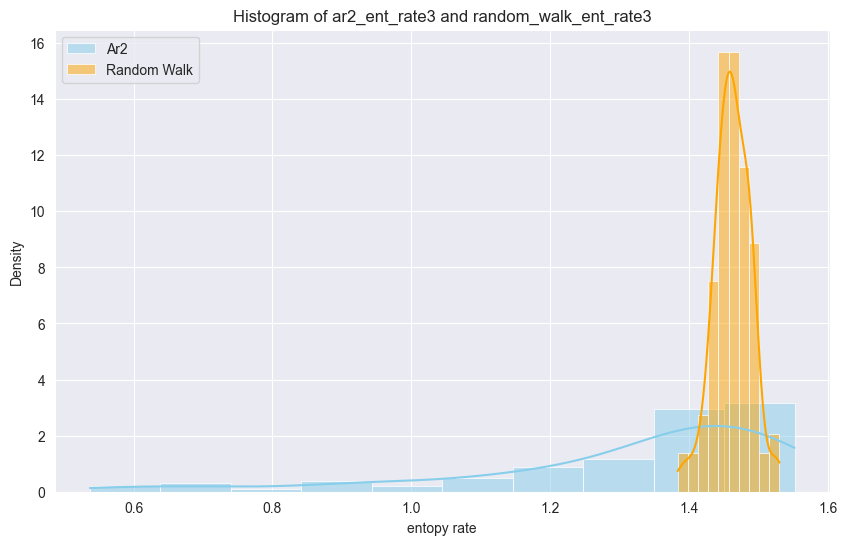

In [8]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['ar2_ent_rate3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Ar2')
sns.histplot(characteristics_df['random_walk_ent_rate3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of ar2_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

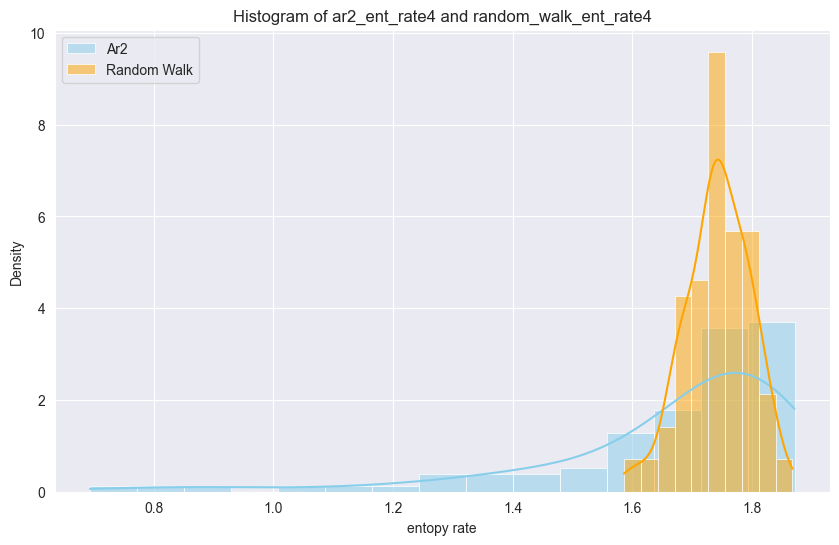

In [9]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['ar2_ent_rate4'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Ar2')
sns.histplot(characteristics_df['random_walk_ent_rate4'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of ar2_ent_rate4 and random_walk_ent_rate4')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

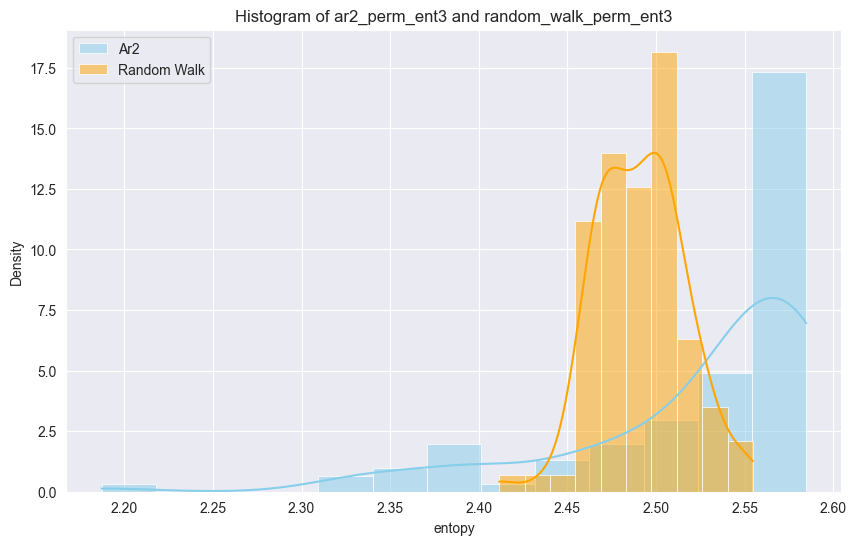

In [10]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['ar2_perm_ent3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Ar2')
sns.histplot(characteristics_df['random_walk_perm_ent3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of ar2_perm_ent3 and random_walk_perm_ent3')
plt.xlabel(f'entropy')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

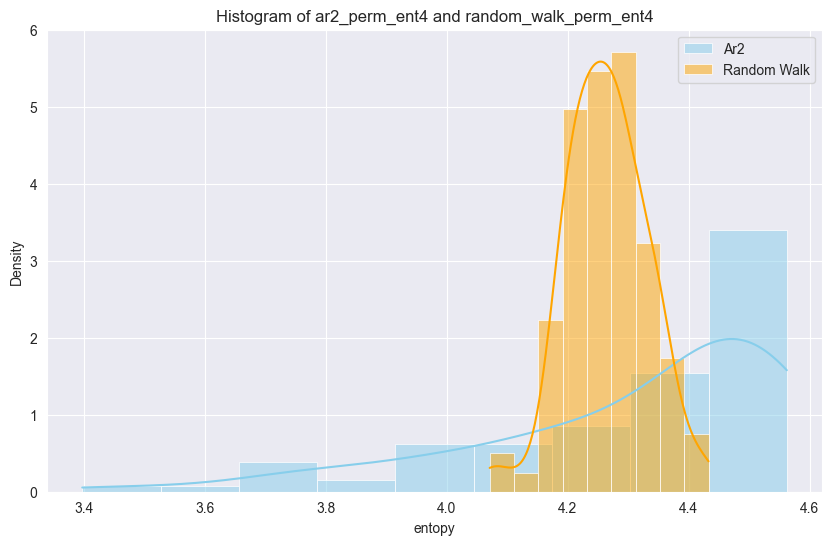

In [11]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['ar2_perm_ent4'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Ar2')
sns.histplot(characteristics_df['random_walk_perm_ent4'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of ar2_perm_ent4 and random_walk_perm_ent4')
plt.xlabel(f'entopy')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

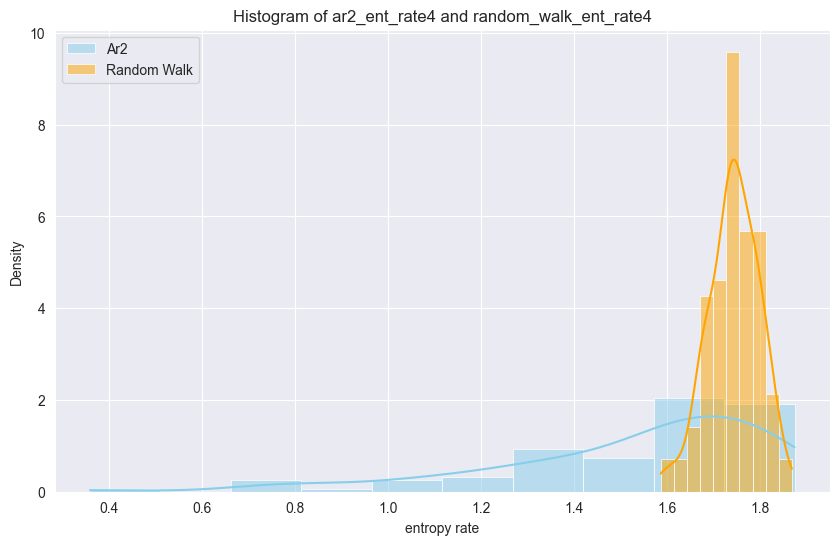

In [12]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['arma_ent_rate4'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Ar2')
sns.histplot(characteristics_df['random_walk_ent_rate4'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of ar2_ent_rate4 and random_walk_ent_rate4')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')

In [33]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['arma_ent_rate3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'ARMA')
sns.histplot(characteristics_df['random_walk_ent_rate3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of arma_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
plt.savefig(f'arma_ent_rate3_histogram1.png', bbox_inches='tight')
plt.close()

In [39]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['arma_perm_ent3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'ARMA')
sns.histplot(characteristics_df['random_walk_perm_ent3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of arma_perm_ent3 and random_walk_perm_ent3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
plt.savefig(f'arma_perm_ent3_histogram1.png', bbox_inches='tight')
plt.close()

In [16]:
print(np.max(characteristics_df["random_walk_perm_ent3"]))
print(np.min(characteristics_df["random_walk_perm_ent3"]))

2.554636436706411
2.4114765956916893


In [25]:
characteristics_df[(characteristics_df["arma_perm_ent3"] > np.max(characteristics_df["random_walk_perm_ent3"])) |
                   (characteristics_df["arma_perm_ent3"] < np.min(characteristics_df["random_walk_perm_ent3"]))].shape

(60, 20)

In [26]:
characteristics_df[(characteristics_df["arma_ent_rate3"] > np.max(characteristics_df["random_walk_ent_rate3"])) |
                   (characteristics_df["arma_ent_rate3"] < np.min(characteristics_df["random_walk_ent_rate3"]))].shape

(63, 20)

Text(0, 0.5, 'Density')

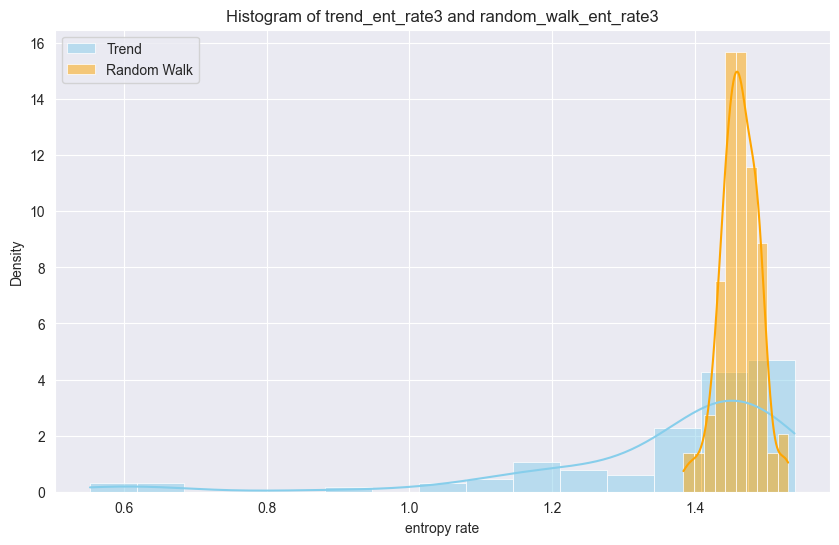

In [35]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cos_ent_rate3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Trend')
sns.histplot(characteristics_df['random_walk_ent_rate3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of trend_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
# plt.savefig(f'arma_ent_rate3_histogram1.png', bbox_inches='tight')
# plt.close()

Text(0, 0.5, 'Density')

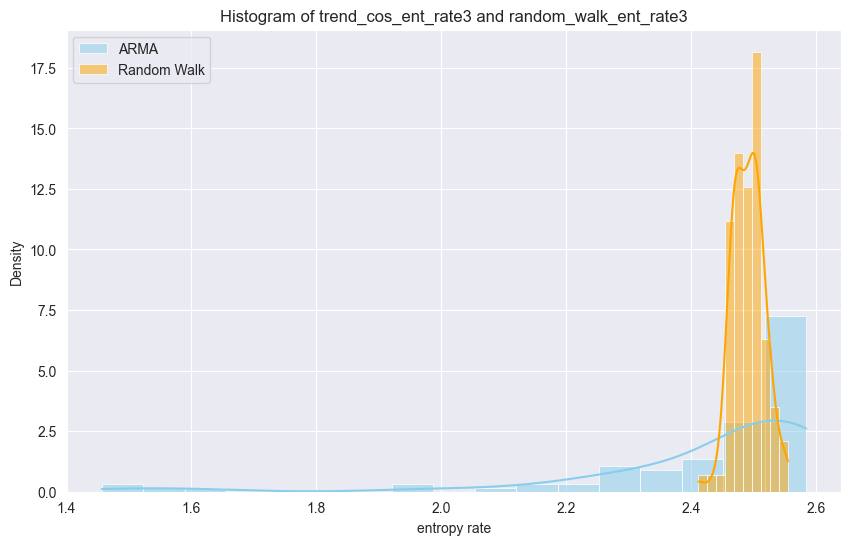

In [38]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cos_perm_ent3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'ARMA')
sns.histplot(characteristics_df['random_walk_perm_ent3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of trend_cos_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
# plt.savefig(f'arma_perm_ent3_histogram1.png', bbox_inches='tight')
# plt.close()

Text(0, 0.5, 'Density')

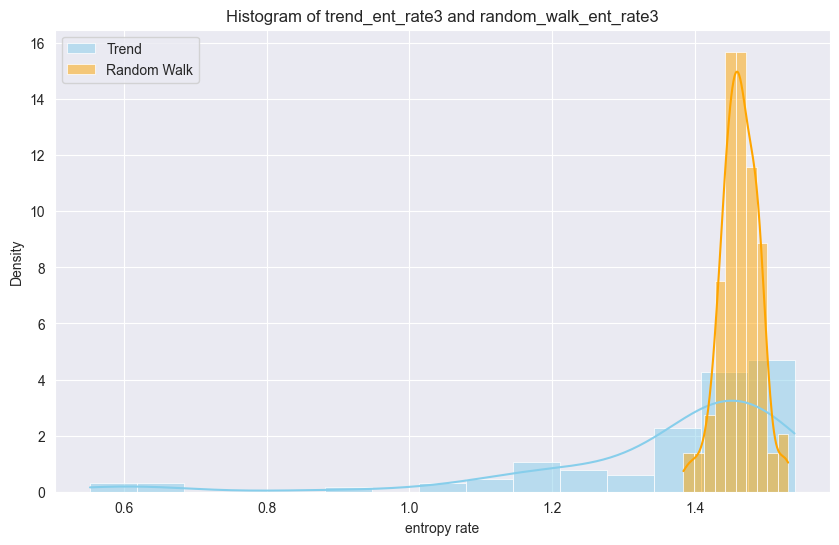

In [47]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cos_ent_rate3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Trend')
sns.histplot(characteristics_df['random_walk_ent_rate3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of trend_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
# plt.savefig(f'arma_ent_rate3_histogram1.png', bbox_inches='tight')
# plt.close()

In [52]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cos_perm_ent3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'ARMA')
sns.histplot(characteristics_df['random_walk_perm_ent3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of trend_cos_perm_ent3 and random_walk_perm_ent3')
plt.xlabel(f'entropy')
plt.ylabel('Density')
plt.savefig(f'trend_perm_ent3_histogram1.png', bbox_inches='tight')
plt.close()

In [51]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cos_ent_rate3_5_jump'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Trend')
sns.histplot(characteristics_df['random_walk_ent_rate3_5_jump'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
plt.legend()
plt.title(f'Histogram of trend_ent_rate3 and random_walk_ent_rate3')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')
plt.savefig(f'trend_ent_rate3_histogram1.png', bbox_inches='tight')
plt.close()

In [53]:
def make_forecast(dataset, forecast_func, forecast_length):
    """
    Make forecasts for each time series in the dataset.

    Parameters:
        dataset (pandas.DataFrame): Input dataset where each row represents a time series.
        forecast_func (function): Function for making forecasts. This function should take a time series
                                  as input and return the forecasted values.
        forecast_length (int): Length of the forecast horizon.

    Returns:
        pandas.DataFrame: DataFrame containing the forecasted values.
    """
    # Create an empty DataFrame to store the forecasted values
    forecasted_dataset = pd.DataFrame(columns=dataset.columns[len(dataset.columns)-forecast_length:])

    # Iterate over each row (time series) in the dataset
    for index, row in dataset.iterrows():
        # Extract the time series
        time_series = row.values
        
        # Make the forecast using the provided function
        forecast = forecast_func(time_series[:len(time_series) - forecast_length], forecast_length)
        
        # Create a new column in the forecasted dataset with the forecasted values
        forecasted_dataset.loc[index] = forecast
    
    return forecasted_dataset

In [54]:
predictions = {"ar2": make_forecast(dataset_df["ar2"], ar2_forecast, 50),
               "arma": make_forecast(dataset_df["arma"], arma_forecast, 50),
               "multifractal": make_forecast(dataset_df["multifractal"], naive_forecast, 50),
               "random_walk": make_forecast(dataset_df["random_walk"], naive_forecast, 50),
               "trend_cos": trend_series_wo_noise.iloc[:, [i for i in range(trend_series_wo_noise.shape[1] - 50, trend_series_wo_noise.shape[1])]]}

C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\vitya\Work\predan\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\vi

In [55]:
from sklearn.metrics import mean_squared_error

def calculate_metrics(real_dataset, predicted_dataset):
    """
    Calculate SMAPE, MASE, and RMSE metrics for each pair of time series in the datasets.

    Parameters:
        real_dataset (pandas.DataFrame): DataFrame containing real values, where each row represents a time series.
        predicted_dataset (pandas.DataFrame): DataFrame containing predicted values, where each row represents a time series.
        
    Returns:
        pandas.DataFrame: DataFrame containing SMAPE, MASE, and RMSE metrics for each pair of time series.
    """
    # Initialize lists to store the metrics
    smape_scores = []
    mase_scores = []
    rmse_scores = []

    # Iterate over each pair of real and predicted time series
    for real_series, predicted_series in zip(real_dataset.values, predicted_dataset.values):
        # Calculate SMAPE
        smape = symmetric_mean_absolute_percentage_error(real_series[len(real_series) - len(predicted_series):], predicted_series)
        smape_scores.append(smape)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(real_series[len(real_series) - len(predicted_series):], predicted_series))
        rmse_scores.append(rmse)

        # Calculate MASE
        mase = mean_absolute_scaled_error(real_series[:len(real_series) - len(predicted_series)], real_series[len(real_series) - len(predicted_series):], predicted_series, 1)
        mase_scores.append(mase)

    # Create a DataFrame to store the metrics
    metrics_df = pd.DataFrame({
        'SMAPE': smape_scores,
        'MASE': mase_scores,
        'RMSE': rmse_scores
    })

    return metrics_df

In [56]:
metrics_df = {'ar2': calculate_metrics(dataset_df["ar2"], predictions['ar2']),
              'arma': calculate_metrics(dataset_df["arma"], predictions['arma']),
              'multifractal': calculate_metrics(dataset_df["multifractal"], predictions['multifractal']),
              'random_walk': calculate_metrics(dataset_df["random_walk"], predictions['random_walk']),
              'trend_cos': calculate_metrics(dataset_df["trend_cos"], predictions['trend_cos'])}

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_perm_ent3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_perm_ent3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_perm_ent3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
# plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_perm_ent4"], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cos_perm_ent3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus permutation entropy')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
#plt.show()
plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
plt.close()

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2_ent_rate3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["arma_ent_rate3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walk_ent_rate3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
# plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_perm_ent4"], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cos_ent_rate3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus entropy rate')
plt.axhline(y=1)
plt.xlabel('MASE')
plt.ylabel('entropy rate')
plt.semilogy()
plt.grid(True)
plt.legend()
#plt.show()
plt.savefig(f'ent_rate3_MASE.png', bbox_inches='tight')
plt.close()

Text(65.34722222222221, 0.5, 'perm ent')

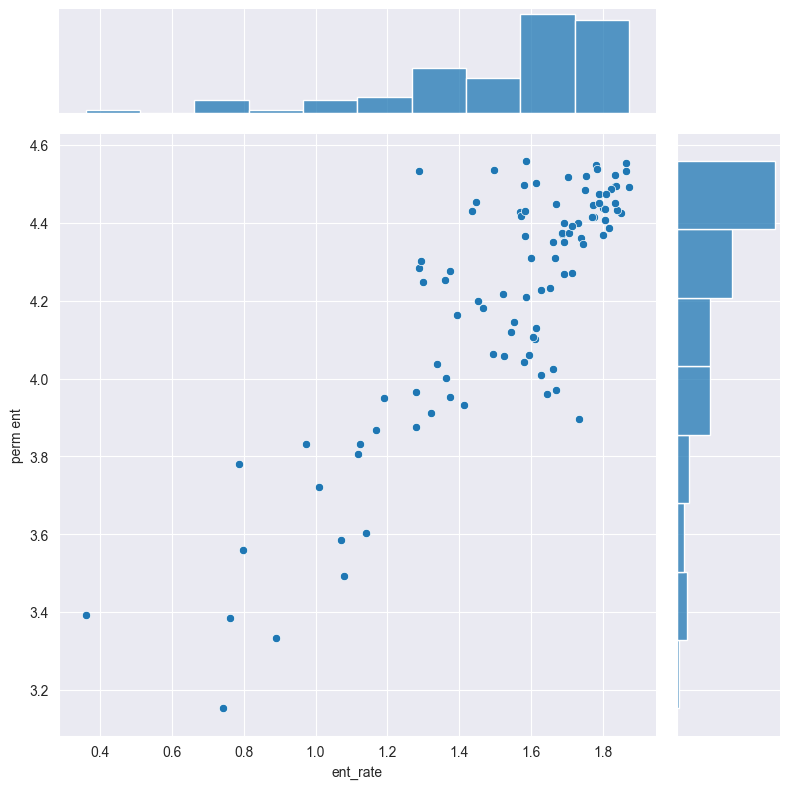

In [80]:
g = sns.JointGrid( x=characteristics_df["arma_ent_rate4"], y=characteristics_df["arma_perm_ent4"], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_joint.set_xlabel('ent_rate')
g.ax_joint.set_ylabel('perm ent')


Text(65.34722222222221, 0.5, 'perm ent')

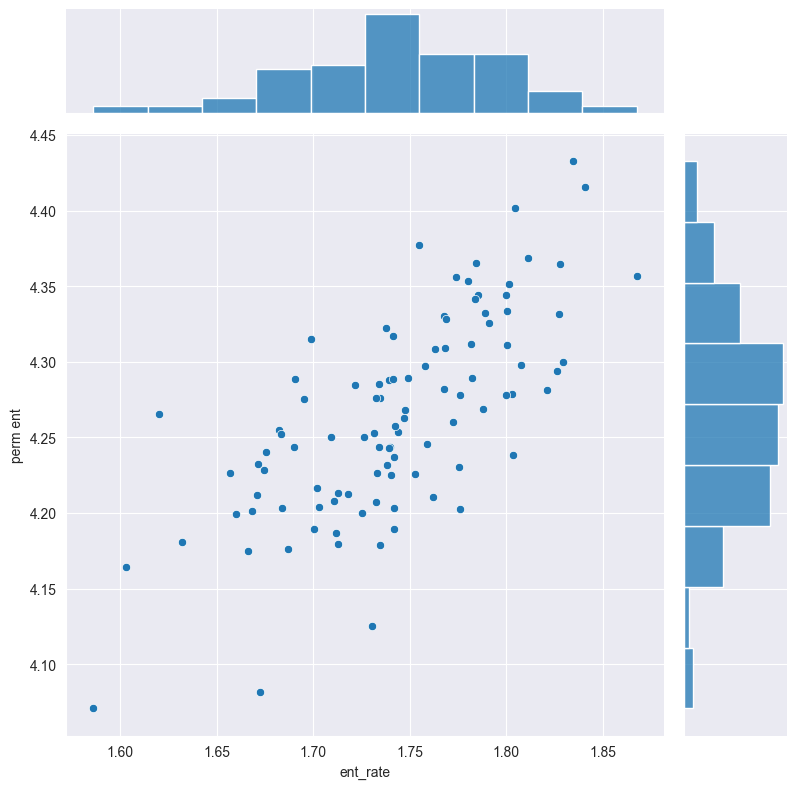

In [81]:
g = sns.JointGrid( x=characteristics_df["random_walk_ent_rate4"], y=characteristics_df["random_walk_perm_ent4"], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_joint.set_xlabel('ent_rate')
g.ax_joint.set_ylabel('perm ent')

In [85]:
q_df = pd.read_csv("../src/features/quaterly_with_ent_rate4.csv", index_col=0)
q_df.head(12)

,ent_rate4,value__sum_values,"value__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.2","value__change_quantiles__f_agg_""mean""__isabs_False__qh_0.8__ql_0.4","value__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8","value__augmented_dickey_fuller__attr_""usedlag""__autolag_""AIC""",value__mean_n_absolute_max__number_of_maxima_7,value__quantile__q_0.1,value__cid_ce__normalize_True,value__variation_coefficient,"value__agg_autocorrelation__f_agg_""median""__maxlag_40","value__agg_autocorrelation__f_agg_""var""__maxlag_40"
Q1,0.512013,180887.003125,65884.041380,-54.404276,3193.375195,2.0,7718.498974,6635.896052,3.600123,0.059901,0.122784,0.589759
Q2,1.515710,186523.583493,89582.423975,-73.835825,4.708505,5.0,8032.877652,6877.840306,3.278226,0.062034,0.044351,0.667796
Q3,1.231307,199910.304733,203665.440916,-95.932132,2530.594913,0.0,8676.982917,7194.621703,3.654678,0.076222,0.031605,0.477528
Q4,0.034689,202918.966414,94823.450799,-106.462815,208.060089,0.0,8667.572608,7534.424773,3.664353,0.057679,-0.041900,0.467195
Q5,0.380779,89192.000000,435258.553583,163.571429,9216.000000,3.0,2489.428571,908.000000,8.888150,0.337892,-0.055220,0.043032
Q6,1.574154,544712.500000,29866.445973,47.487500,5801.519375,11.0,9659.228571,8911.000000,6.694099,0.029568,0.024280,0.103792
Q7,2.079328,197259.000000,3293.005390,5.515385,2041.712222,1.0,3476.714286,3231.840000,6.270432,0.025117,-0.023414,0.138282
Q8,1.609675,147600.900000,2525.733775,9.254545,722.991875,6.0,2613.757143,2402.500000,7.789991,0.028098,0.070915,0.106406
Q9,1.463068,154024.300000,23071.324082,-4.405263,145.215000,11.0,2858.228571,2387.280000,7.137009,0.064482,-0.287419,0.136353
Q10,1.688620,148635.900000,1032.326775,9.553846,1020.848000,11.0,2674.914286,2402.320000,7.578566,0.036655,-0.160970,0.062604


In [86]:
perm_q = pd.read_csv("../src/features/quater_ent_norm4.csv", index_col=0)
perm_q.head(12)

,perm_ent3,perm_ent4,mse,mape,sym_test,w_perm_ent4,smape,mase,max_diff,amplitude,...,stat_entropy1,stat_entropy2,stat_entropy3,stat_entropy4,stat_entropy5,tran_entropy1,tran_entropy2,tran_entropy3,tran_entropy4,tran_entropy5
Q1,NaN,0.818860,22333.057123,0.017638,True,0.470761,0.017467,0.386888,398.315999,1344.145321,...,3.690371,3.690414,3.690413,3.690413,3.690413,1.966157,2.784570,3.548322,4.123239,4.586118
Q2,NaN,0.779205,24564.254223,0.018605,True,0.496908,0.018422,0.363980,516.798168,1422.576544,...,3.446439,3.446439,3.446439,3.446439,3.446439,2.697682,4.424622,5.569147,6.507722,7.060409
Q3,NaN,0.698904,7767.906622,0.008752,True,0.474837,0.008720,0.172401,469.932322,1561.741992,...,3.184375,3.184375,3.184375,3.184375,3.184375,2.651720,4.745983,6.124130,6.969372,7.509469
Q4,NaN,0.738144,15323.172700,0.010606,True,0.489102,0.010475,0.251886,505.660807,1355.150018,...,0.555699,0.055318,0.004963,0.000421,0.000034,1.930209,3.337207,4.712708,6.319447,8.003970
Q5,NaN,0.612547,16146.143062,0.084324,True,0.471352,0.088779,0.702161,737.000000,2386.000000,...,2.798176,2.798971,2.813308,2.812514,2.798176,2.942084,4.328168,5.195484,5.766628,6.111984
Q6,NaN,0.808890,2239.235550,0.003648,True,0.330748,0.003637,0.237438,219.400000,913.900000,...,3.717456,3.717453,3.717453,3.717453,3.717453,1.503222,2.866728,4.466826,5.458959,6.166832
Q7,NaN,0.946538,89.949617,0.002453,True,0.334904,0.002452,0.173123,81.900000,331.900000,...,4.304221,4.304221,4.304221,4.304221,4.304221,1.068109,2.297415,3.454227,4.224442,4.737096
Q8,NaN,0.881834,521.680493,0.006634,True,0.318113,0.006612,0.372718,66.100000,285.800000,...,4.021856,4.021859,4.021859,4.021859,4.021859,1.265983,2.583883,3.587500,4.422808,4.990874
Q9,NaN,0.840363,162.439167,0.004116,False,0.453126,0.004114,0.203397,64.500000,541.000000,...,3.853037,3.853035,3.853035,3.853035,3.853035,1.314010,2.455730,3.670920,4.959682,5.811256
Q10,NaN,0.819360,152.719215,0.002963,False,0.420651,0.002954,0.176417,71.700000,390.200000,...,3.748438,3.748438,3.748438,3.748438,3.748438,1.692713,2.926714,4.351670,5.327515,6.047557


In [87]:
print(q_df.shape)
print(perm_q.shape)

(24000, 12)
(24000, 38)


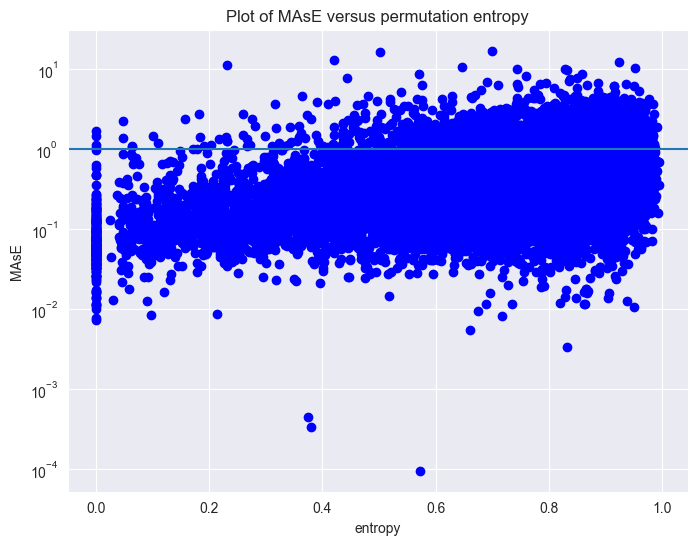

In [90]:
plt.figure(figsize=(8, 6))
plt.scatter(perm_q["perm_ent4"], perm_q['mase'], color='blue')
plt.title('Plot of MAsE versus permutation entropy')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

Text(65.34722222222221, 0.5, 'mase')

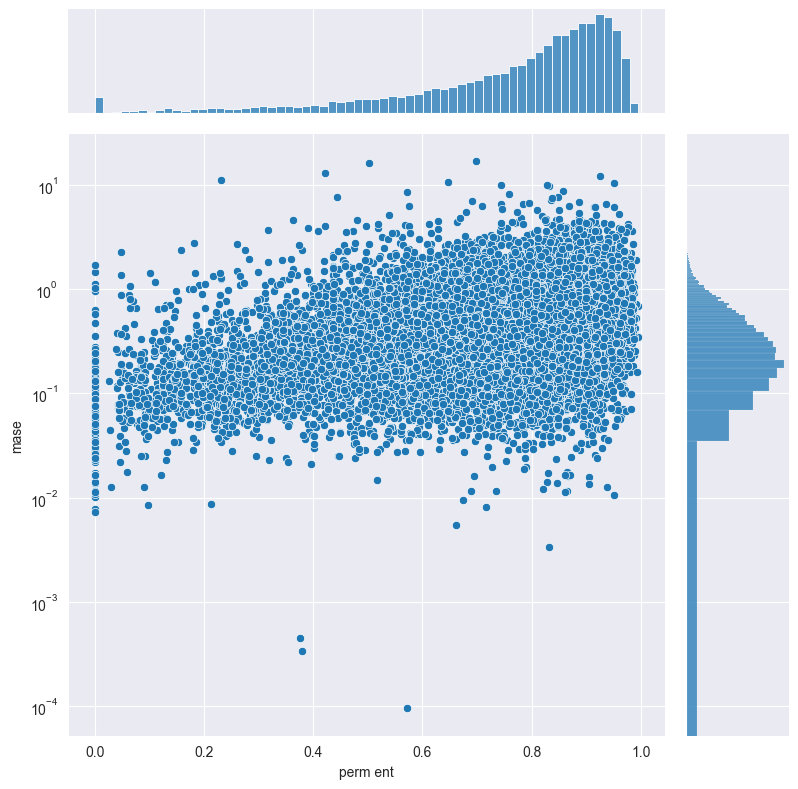

In [93]:
g = sns.JointGrid( x=perm_q["perm_ent4"], y=perm_q['mase'], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('perm ent')
g.ax_joint.set_ylabel('mase')

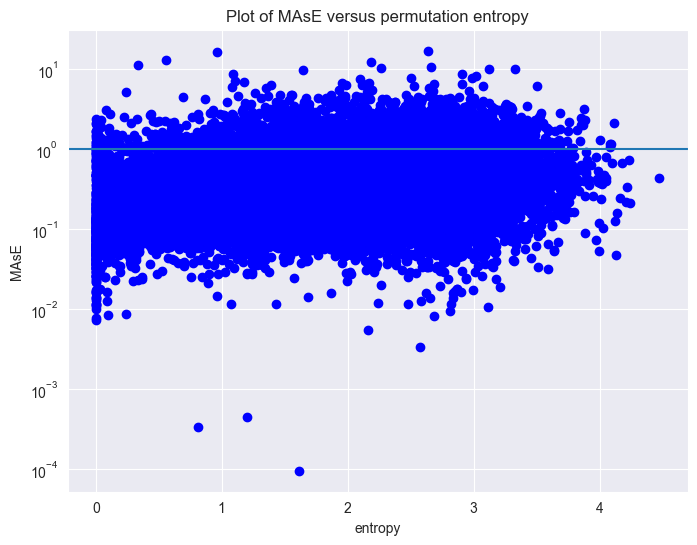

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(q_df["ent_rate4"], perm_q['mase'], color='blue', label='AR(2)')
plt.title('Plot of MAsE versus permutation entropy')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

Text(65.34722222222221, 0.5, 'mase')

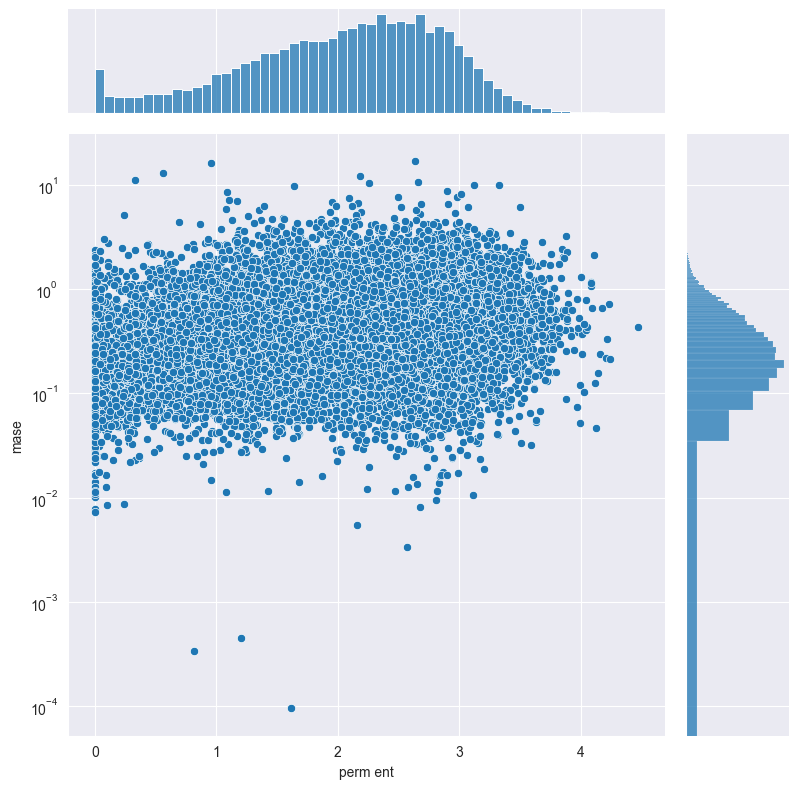

In [94]:
g = sns.JointGrid( x=q_df["ent_rate4"], y=perm_q['mase'], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('perm ent')
g.ax_joint.set_ylabel('mase')

In [105]:
perm_q["ent_rate4"] = q_df['ent_rate4']
perm_q['MAsE > 1'] = perm_q['mase'] > 1
g = sns.jointplot(
    data=perm_q,
    x="ent_rate4", y="perm_ent4", hue="MAsE > 1",
    kind="scatter", palette={True: "r", False: "b"})
g.fig.suptitle('Распределение entropy rate и permutation entropy для различных MAsE', fontsize=16)
g.fig.subplots_adjust(top=0.92)  # Корректировка положения заголовка
g.savefig('jointplot_real_data.png', bbox_inches='tight')

plt.close()

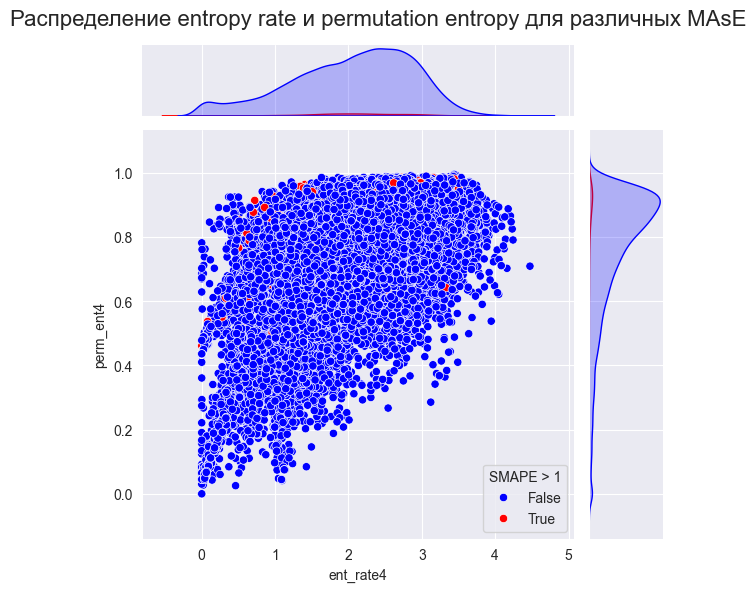

In [109]:
perm_q["ent_rate4"] = q_df['ent_rate4']
perm_q['SMAPE > 1'] = perm_q['smape'] > 0.3
g = sns.jointplot(
    data=perm_q,
    x="ent_rate4", y="perm_ent4", hue="SMAPE > 1",
    kind="scatter", palette={True: "r", False: "b"})
g.fig.suptitle('Распределение entropy rate и permutation entropy для различных MAsE', fontsize=16)
g.fig.subplots_adjust(top=0.92)  # Корректировка положения заголовка

<Axes: >

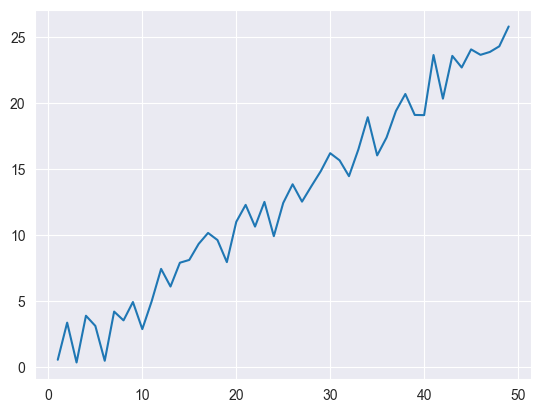

In [12]:
dataset_df['trend_cos'].iloc[4, list(range(1,50))].plot()